In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/Preprocessed_data.csv")

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Sort data
df = df.sort_values('Date')

# Extract unique years
years = sorted(df['Date'].dt.year.unique())

print("Years in dataset:", years)

# Create dictionary of yearly data
year_data = {}

for year in years:
    year_df = df[df['Date'].dt.year == year].copy()
    year_df = year_df.sort_values('Date').reset_index(drop=True)
    
    year_data[year] = year_df
    print(f"Year {year} -> {len(year_df)} observations")

Years in dataset: [2013, 2014, 2015, 2016, 2017]
Year 2013 -> 1547 observations
Year 2014 -> 1549 observations
Year 2015 -> 1542 observations
Year 2016 -> 1547 observations
Year 2017 -> 1538 observations


In [2]:
# Check columns
print(df.columns)


Index(['station', 'Date', 'Present_Tmax', 'Present_Tmin', 'LDAPS_RHmin',
       'LDAPS_RHmax', 'LDAPS_Tmax_lapse', 'LDAPS_Tmin_lapse', 'LDAPS_WS',
       'LDAPS_LH', 'LDAPS_CC1', 'LDAPS_CC2', 'LDAPS_CC3', 'LDAPS_CC4',
       'LDAPS_PPT1', 'LDAPS_PPT2', 'LDAPS_PPT3', 'LDAPS_PPT4', 'lat', 'lon',
       'DEM', 'Slope', 'Solar radiation', 'Next_Tmax', 'Next_Tmin'],
      dtype='object')


In [3]:
# Create dictionary for (year, station) data
grouped_data = {}

for year in years:
    year_df = year_data[year]
    
    stations = year_df['station'].unique()
    
    for st in stations:
        st_df = year_df[year_df['station'] == st].copy()
        st_df = st_df.sort_values('Date').reset_index(drop=True)
        
        # Only keep if enough data points
        if len(st_df) > 30:
            grouped_data[(year, st)] = st_df

print("Total (year, station) series:", len(grouped_data))

# Show one example
sample_key = list(grouped_data.keys())[0]
print("Sample key:", sample_key)
print("Sample length:", len(grouped_data[sample_key]))

Total (year, station) series: 125
Sample key: (2013, 1.0)
Sample length: 62


In [4]:
train_test_data = {}

for key, df_st in grouped_data.items():
    
    series = df_st['Next_Tmax']
    
    split_idx = int(len(series) * 0.8)
    
    train = series.iloc[:split_idx]
    test = series.iloc[split_idx:]
    
    train_test_data[key] = (train, test)

# Check one example
sample_key = list(train_test_data.keys())[0]
train_sample, test_sample = train_test_data[sample_key]

print("Sample key:", sample_key)
print("Train size:", len(train_sample))
print("Test size:", len(test_sample))

Sample key: (2013, 1.0)
Train size: 49
Test size: 13


In [5]:
from statsmodels.tsa.stattools import adfuller

# Take one sample series (train data)
sample_key = list(train_test_data.keys())[0]
train_sample, test_sample = train_test_data[sample_key]

# ADF test
result = adfuller(train_sample)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -0.9929203163235307
p-value: 0.7558376868558228


In [6]:
# Apply first differencing
train_diff = train_sample.diff().dropna()

# Run ADF again
result_diff = adfuller(train_diff)

print("ADF Statistic after differencing:", result_diff[0])
print("p-value after differencing:", result_diff[1])

ADF Statistic after differencing: -4.740027384729587
p-value after differencing: 7.072900820920557e-05


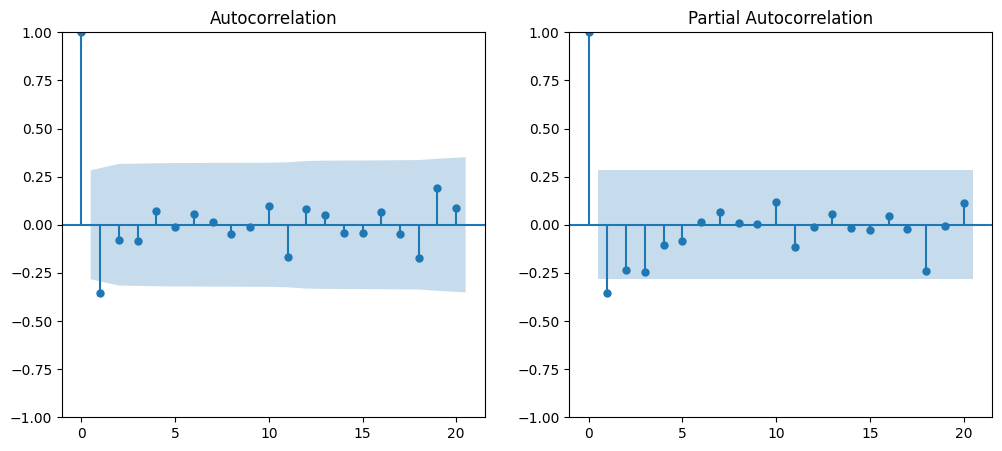

In [7]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_acf(train_diff, ax=plt.gca(), lags=20)

plt.subplot(1,2,2)
plot_pacf(train_diff, ax=plt.gca(), lags=20)

plt.show()

In [8]:
from statsmodels.tsa.arima.model import ARIMA

# Fit model
model = ARIMA(train_sample, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:              Next_Tmax   No. Observations:                   49
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -100.283
Date:                Fri, 10 Apr 2026   AIC                            206.565
Time:                        18:13:16   BIC                            212.179
Sample:                             0   HQIC                           208.687
                                 - 49                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1435      0.265      0.542      0.588      -0.376       0.663
ma.L1         -0.7000      0.202     -3.462      0.001      -1.096      -0.304
sigma2         3.7830      1.020      3.708      0.0

In [9]:
# Forecast
forecast = model_fit.forecast(steps=len(test_sample))

# Compare first few values
print("Forecast:", forecast.values[:5])
print("Actual:", test_sample.values[:5])

Forecast: [29.60966694 29.61105422 29.6112533  29.61128187 29.61128597]
Actual: [30.3 30.1 30.8 30.4 26. ]


In [10]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test_sample, forecast))

print("RMSE:", rmse)

RMSE: 2.4425032543703655


In [11]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_list = []

for key, (train, test) in train_test_data.items():
    try:
        model = ARIMA(train, order=(1,1,1))
        model_fit = model.fit()
        
        forecast = model_fit.forecast(steps=len(test))
        
        rmse = np.sqrt(mean_squared_error(test, forecast))
        rmse_list.append(rmse)
        
    except:
        continue

# Final result
avg_rmse = np.mean(rmse_list)

print("Average RMSE across all series:", avg_rmse)
print("Number of valid series:", len(rmse_list))

C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\DELL

Average RMSE across all series: 3.6178969529321536
Number of valid series: 125


In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Get sample
sample_key = list(train_test_data.keys())[0]
df_sample = grouped_data[sample_key]

# Split index
split_idx = int(len(df_sample) * 0.8)

train_df = df_sample.iloc[:split_idx]
test_df = df_sample.iloc[split_idx:]

# Target
y_train = train_df['Next_Tmax']
y_test = test_df['Next_Tmax']

# Exogenous variables
features = ['LDAPS_Tmax_lapse']
X_train = train_df[features]
X_test = test_df[features]

In [13]:
print("Sample key:", sample_key)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nSample X_train:")
print(X_train.head())

print("\nSample y_train:")
print(y_train.head())

Sample key: (2013, 1.0)
Train shape: (49, 25)
Test shape: (13, 25)
X_train shape: (49, 1)
X_test shape: (13, 1)

Sample X_train:
   LDAPS_Tmax_lapse
0         28.074101
1         25.276716
2         27.785497
3         28.125651
4         30.458252

Sample y_train:
0    29.1
1    24.8
2    28.1
3    25.2
4    28.0
Name: Next_Tmax, dtype: float64


In [14]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit SARIMAX
model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1,1,1),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)

print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:              Next_Tmax   No. Observations:                   49
Model:               SARIMAX(1, 1, 1)   Log Likelihood                 -79.969
Date:                Fri, 10 Apr 2026   AIC                            167.937
Time:                        18:13:25   BIC                            175.252
Sample:                             0   HQIC                           170.677
                                 - 49                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
LDAPS_Tmax_lapse     0.7907      0.167      4.736      0.000       0.464       1.118
ar.L1                0.1090      0.208      0.524      0.600      -0.299       0.517
ma.L1               -0.8473 

In [15]:
# Forecast using exogenous test data
forecast = model_fit.forecast(steps=len(y_test), exog=X_test)

# Compare first few values
print("Forecast:", forecast.values[:5])
print("Actual:", y_test.values[:5])

Forecast: [29.75412371 30.43862136 30.97327831 31.11469882 27.54310931]
Actual: [30.3 30.1 30.8 30.4 26. ]


In [16]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_sarimax = np.sqrt(mean_squared_error(y_test, forecast))

print("SARIMAX RMSE:", rmse_sarimax)

SARIMAX RMSE: 0.8919009860941083


In [17]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_list_sarimax = []

for key, df_st in grouped_data.items():
    try:
        split_idx = int(len(df_st) * 0.8)
        
        train_df = df_st.iloc[:split_idx]
        test_df = df_st.iloc[split_idx:]
        
        y_train = train_df['Next_Tmax']
        y_test = test_df['Next_Tmax']
        
        X_train = train_df[['LDAPS_Tmax_lapse']]
        X_test = test_df[['LDAPS_Tmax_lapse']]
        
        model = SARIMAX(
            y_train,
            exog=X_train,
            order=(1,1,1),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        
        model_fit = model.fit(disp=False)
        
        forecast = model_fit.forecast(steps=len(y_test), exog=X_test)
        
        rmse = np.sqrt(mean_squared_error(y_test, forecast))
        rmse_list_sarimax.append(rmse)
        
    except:
        continue

print("Average SARIMAX RMSE:", np.mean(rmse_list_sarimax))
print("Number of series:", len(rmse_list_sarimax))

Average SARIMAX RMSE: 1.3988136653868704
Number of series: 125
